In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
from skimage import io
from skimage import color
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

In [2]:
import matplotlib as mpl
print("axes.grid = ", mpl.rcParams['axes.grid'])
mpl.rcParams['axes.grid'] = False

axes.grid =  False


Prikaz originalne slike i RGB komponenti

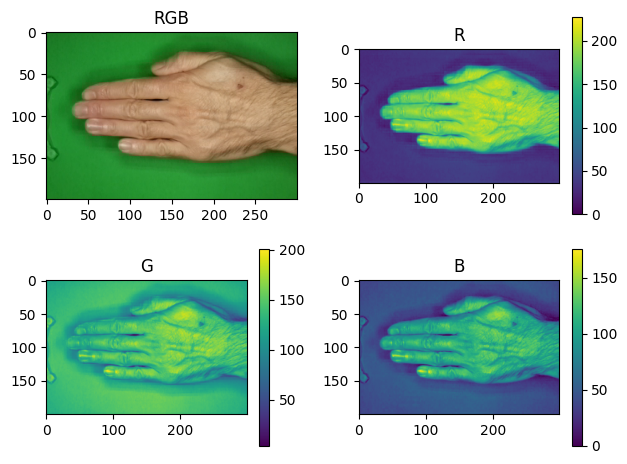

In [3]:
image = io.imread('Rock Paper Scissors/paper/0a3UtNzl5Ll3sq8K.png')

fig, ax = plt.subplots(2, 2)
im0 = ax[0, 0].imshow(image)
ax[0, 0].set_title('RGB')
im1 = ax[0, 1].imshow(image[:, :, 0])
ax[0, 1].set_title('R')
fig.colorbar(im1)
im2 = ax[1, 0].imshow(image[:, :, 1])
ax[1, 0].set_title('G')
fig.colorbar(im2)
im3 = ax[1, 1].imshow(image[:, :, 2])
ax[1, 1].set_title('B')
fig.colorbar(im3)
plt.tight_layout()
plt.show()

Maska u RGB - proba

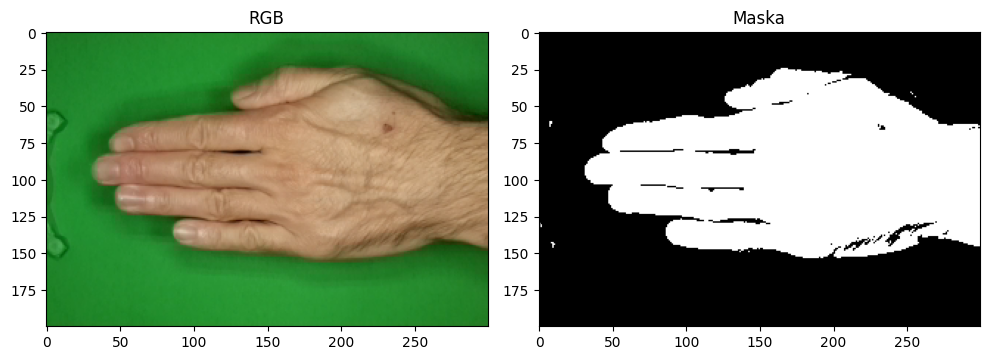

In [4]:
r = image[:, :, 0]
g = image[:, :, 1]
b = image[:, :, 2]
mask = (r >= 70) & (b >= 60)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
im1 = ax[0].imshow(image)
ax[0].set_title('RGB')
im2 = ax[1].imshow(mask, cmap='gray')
ax[1].set_title('Maska')
plt.tight_layout()
plt.show()

Iako je na ovom primeru i u RGB prostoru dobijena dobra maska (pragovanjem po R i B kanalima), takav pristup je osetljiviji na promene osvetljenja, senke i refleksije. Zbog toga je pogodnije koristiti HSV prostor, u kome su nijansa boje (H), zasićenost (S) i osvetljenost (V) razdvojeni, pa je segmentacija robusnija pri različitim uslovima osvetljenja.

Prikaz HSV komponenti

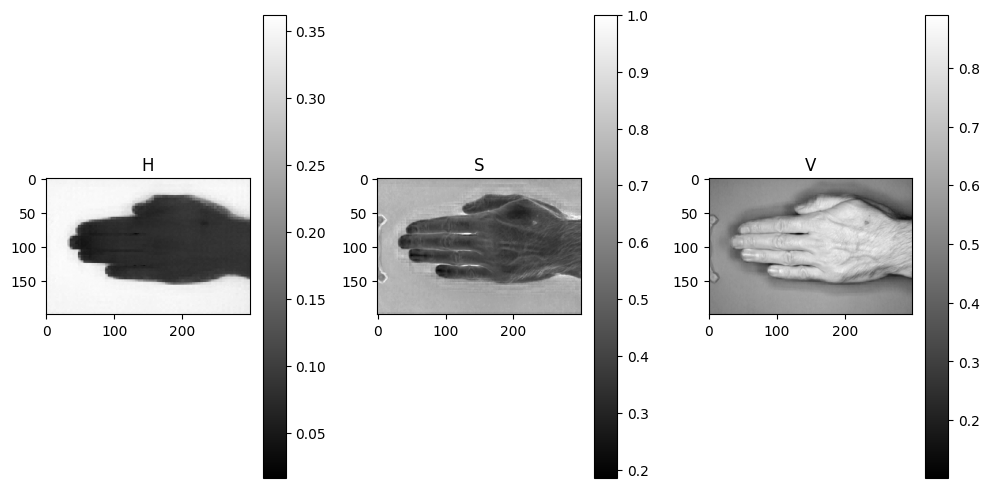

In [27]:
image_hsv = color.rgb2hsv(image)
h = image_hsv[:, :, 0]
s = image_hsv[:, :, 1]
v = image_hsv[:, :, 2]

fig, ax = plt.subplots(1, 3, figsize=(10, 5))
im0 = ax[0].imshow(image_hsv[:, :, 0], cmap = 'gray')
ax[0].set_title('H')
fig.colorbar(im0)
im1 = ax[1].imshow(image_hsv[:, :, 1], cmap = 'gray')
ax[1].set_title('S')
fig.colorbar(im1)
im2 = ax[2].imshow(image_hsv[:, :, 2], cmap = 'gray')
ax[2].set_title('V')
fig.colorbar(im2)
plt.tight_layout()
plt.show()

In [6]:
mask = (h >= 0.02) & (h <= 0.25) & (s >= 0.20) & (s <= 0.65)

Isecanje

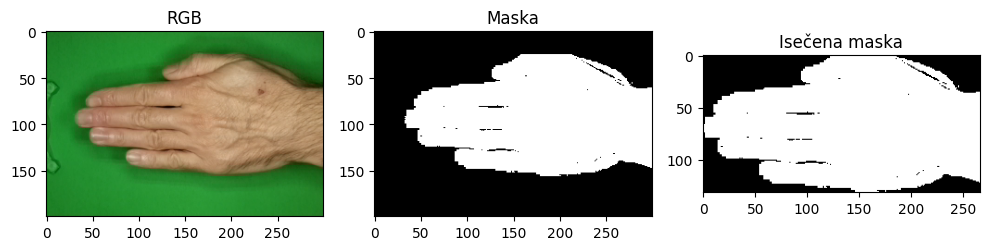

In [7]:
coords = np.argwhere(mask)
y0, x0 = coords.min(axis=0)
y1, x1 = coords.max(axis=0)
    
cropped = mask[y0:y1+1, x0:x1+1]

fig, ax = plt.subplots(1, 3, figsize=(10, 5))
im0 = ax[0].imshow(image)
ax[0].set_title('RGB')
im1 = ax[1].imshow(mask, cmap='gray')
ax[1].set_title('Maska')
im2 = ax[2].imshow(cropped, cmap='gray')
ax[2].set_title('Isečena maska')
plt.tight_layout()
plt.show()

Fja za predobradu slike sa odredjenim pragovima

In [8]:
def edit(image):
    image_hsv = color.rgb2hsv(image)
    h = image_hsv[:, :, 0]
    s = image_hsv[:, :, 1]
    v = image_hsv[:, :, 2]
    mask = (h >= 0.02) & (h <= 0.25) & (s >= 0.20) & (s <= 0.65)
    coords = np.argwhere(mask)
    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0)
    cropped = mask[y0:y1 + 1, x0:x1 + 1]
    
    return cropped
    

Fja za izracunavanje vrednosti obelezja

In [9]:
def extraction(cropped):
    M, N = np.shape(cropped) # redovi (visina), kolone (sirina)
    
    # obeležje 1 -> koji procenat belih piksela je u levoj polovini
    total_white = np.sum(cropped == 1)
    left_half = cropped[:, :N//2]
    left_white = np.sum(left_half == 1) 
    f1 = left_white / total_white * 100

    # obeležje 2 -> odnos sirine i visine slike u procentima
    f2 = N/M * 100

    # obeležje 3 -> u levoj cetvrtini slike koji je procenat belih piksela
    left_q = cropped[:, :N//4]
    left_q_white = np.sum(left_q == 1)
    f3 = left_q_white / (M * N//4) * 100
    
    return f1, f2, f3

Fja koja će da prođe kroz folder sa slikama i da za svaku sračuna obeležja koja zatim pakujemo u matricu odgovarajućih dimenzija

In [10]:
def features_all(folder):
    
    features = []
    for filename in os.listdir(folder):
        image_path = os.path.join(folder, filename)
        img = io.imread(image_path)
        imgedited = edit(img)
        features.append(extraction(imgedited))

    return features

Lista obelezja za svaki folder

In [11]:
paper = 'Rock Paper Scissors/paper'
rock = 'Rock Paper Scissors/rock'
scissors = 'Rock Paper Scissors/scissors'

paper_features = features_all(paper)
rock_features = features_all(rock)
scissors_features = features_all(scissors)

Konverzija iz liste tuplova u matrice nx3

In [12]:
paper_array = np.array(paper_features, dtype=np.float64)
rock_array = np.array(rock_features, dtype=np.float64)
scissors_array = np.array(scissors_features, dtype=np.float64)

Posto imamo 3 obelezja, prikazacemo 3 grafika, na svakom po 2:

Prikaz klasa po obelezjima 1 i 2

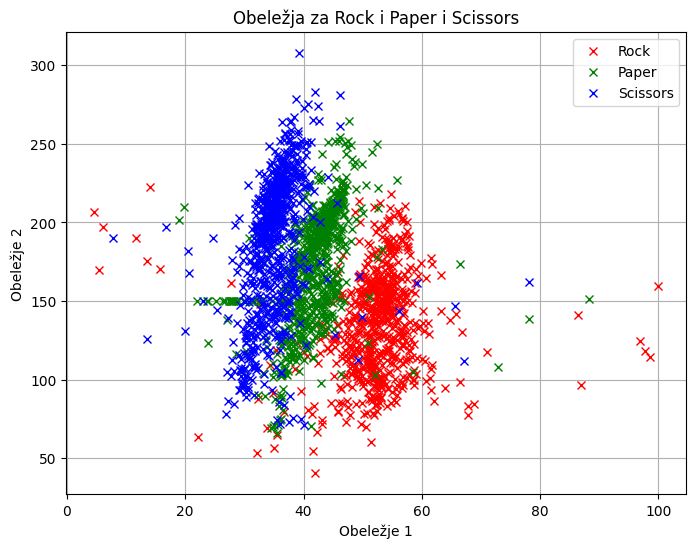

In [13]:
plt.figure(figsize=(8, 6))
plt.plot(rock_array[:, 0], rock_array[:, 1], 'rx', label='Rock')  
plt.plot(paper_array[:, 0], paper_array[:, 1], 'gx', label='Paper')  
plt.plot(scissors_array[:, 0], scissors_array[:, 1], 'bx', label='Scissors') 

plt.xlabel('Obeležje 1')
plt.ylabel('Obeležje 2')
plt.title('Obeležja za Rock i Paper i Scissors')
plt.legend()
plt.grid()
plt.show()

Prikaz klasa po obelezjima 1 i 3


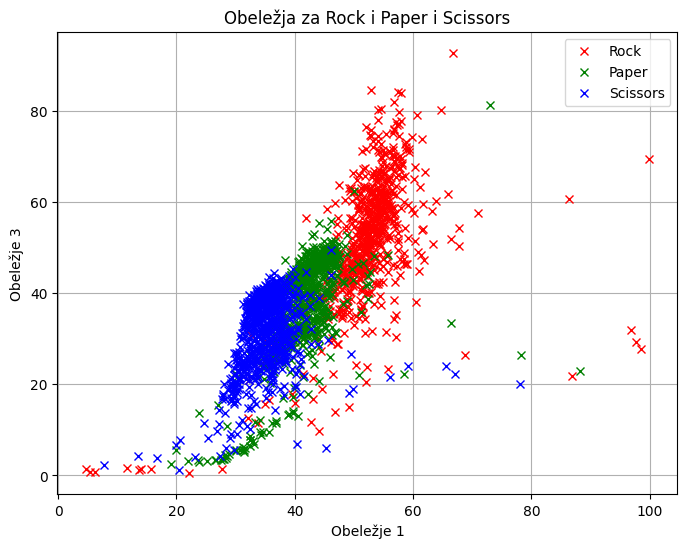

In [14]:
plt.figure(figsize=(8, 6))
plt.plot(rock_array[:, 0], rock_array[:, 2], 'rx', label='Rock')  
plt.plot(paper_array[:, 0], paper_array[:, 2], 'gx', label='Paper')  
plt.plot(scissors_array[:, 0], scissors_array[:, 2], 'bx', label='Scissors') 

plt.xlabel('Obeležje 1')
plt.ylabel('Obeležje 3')
plt.title('Obeležja za Rock i Paper i Scissors')
plt.legend()
plt.grid()
plt.show()

Prikaz klasa po obelezjima 2 i 3

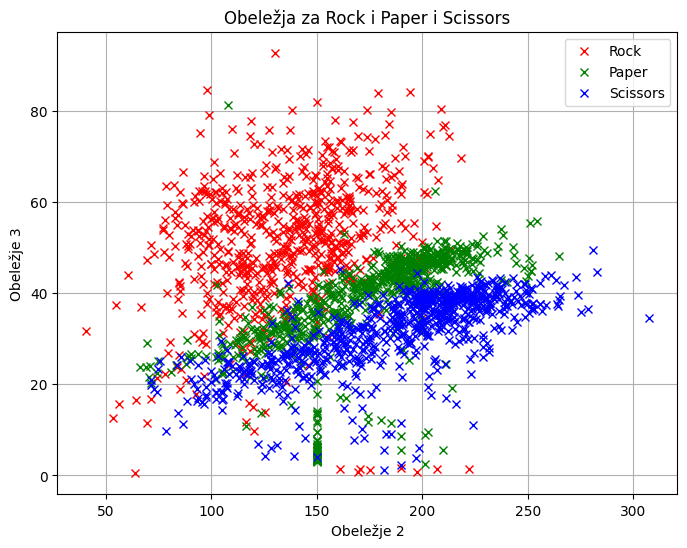

In [15]:
plt.figure(figsize=(8, 6))
plt.plot(rock_array[:, 1], rock_array[:, 2], 'rx', label='Rock')  
plt.plot(paper_array[:, 1], paper_array[:, 2], 'gx', label='Paper')  
plt.plot(scissors_array[:, 1], scissors_array[:, 2], 'bx', label='Scissors') 

plt.xlabel('Obeležje 2')
plt.ylabel('Obeležje 3')
plt.title('Obeležja za Rock i Paper i Scissors')
plt.legend()
plt.grid()
plt.show()

S obzirom da su sva obeležja računata u procentima, odnosno već su na istoj skali, ne moramo da vršimo normalizaciju.

Podela skupa podataka

In [16]:
X = np.concatenate((rock_array, paper_array, scissors_array), axis = 0)
num_rock = np.shape(rock_array)[0]
num_paper = np.shape(paper_array)[0]
num_scissors = np.shape(scissors_array)[0]
print(num_rock, num_paper, num_scissors)

Y = np.concatenate((np.zeros((num_rock, 1)), np.ones((num_paper, 1)), 2 * np.ones((num_scissors, 1))), axis = 0)

Xtrain, Xtest, Ytrain, Ytest = train_test_split(X, Y, test_size = 0.2, random_state = 42, stratify = Y, shuffle = True)

print(Xtrain.shape)

669 712 750
(1704, 3)


Vidimo da su klase priblizno izbalansirane tako da necemo primenjivati neku od tehnika za balansiranje. Podelu cemo izvrsiti u odnosu 80:20, bez val skupa. S obzirom da imamo 3 klase, za klasifikaciju cemo koristiti test vise hipoteza. Za njegovu primenu prvo moramo da procenimo srednje vrednosti i kovarijacione matrice svake od klasa (na train skupu), uz pretpostavku o normalnoj raspodeli.  

Procena srednjih vrednosti i cov matrica

In [17]:
Ytrain = Ytrain.reshape(Ytrain.shape[0], )

Xtrain_rock = Xtrain[Ytrain == 0]
Xtrain_paper = Xtrain[Ytrain == 1]
Xtrain_scissors = Xtrain[Ytrain == 2]

M0 = np.mean(Xtrain_rock, axis = 0)
M1 = np.mean(Xtrain_paper, axis = 0)
M2 = np.mean(Xtrain_scissors, axis = 0)

S0 = np.cov(Xtrain_rock, rowvar = False) # izmedju kolona, ne redova
S1 = np.cov(Xtrain_paper, rowvar = False)
S2 = np.cov(Xtrain_scissors, rowvar = False)

print(S0, S1, S2)

[[  56.58275825   17.5245461    69.02429731]
 [  17.5245461  1034.09525381  125.88302743]
 [  69.02429731  125.88302743  206.15913215]] [[  29.57300649   72.00231675   36.57801652]
 [  72.00231675 1267.33179604  240.2942289 ]
 [  36.57801652  240.2942289   121.44822454]] [[  17.92941057   57.33021505   10.31302582]
 [  57.33021505 1866.62967307  250.43727542]
 [  10.31302582  250.43727542   67.33395506]]


Fja za racunanje fgv slucajnog vektora normalne raspodele

In [18]:
def gaussian_pdf(X, M, S):
    d = M.shape[0]
    detS = np.linalg.det(S)
    invS = np.linalg.inv(S)
    diff = X - M
    exponent = -0.5 * diff.T @ invS @ diff
    f = (1 / ((2 * np.pi)**(d/2) * detS**0.5)) * np.exp(exponent)
    return f

Procena apriornih verovatnoca

In [19]:
P0 = Xtrain_rock.shape[0] / Xtrain.shape[0]
P1 = Xtrain_paper.shape[0] / Xtrain.shape[0]
P2 = Xtrain_scissors.shape[0] / Xtrain.shape[0]

print(P0, P1, P2)

0.31396713615023475 0.33392018779342725 0.352112676056338


Predikcije - smestamo u klasu sa najvecim qi = P(wi | x)

In [20]:
Ypred = []
for x in Xtest:
    f0 = gaussian_pdf(x, M0, S0)
    f1 = gaussian_pdf(x, M1, S1)
    f2 = gaussian_pdf(x, M2, S2)
    probs = [P0 * f0, P1 * f1, P2 * f2]
    Ypred.append(np.argmax(probs))
    
Ypred = np.array(Ypred)
Ytest = Ytest.reshape(Ytest.shape[0], )
print(Ytest.shape)
print(Ypred.shape)    

(427,)
(427,)


Evaluacija

Tacnost je 94.14519906323186 %


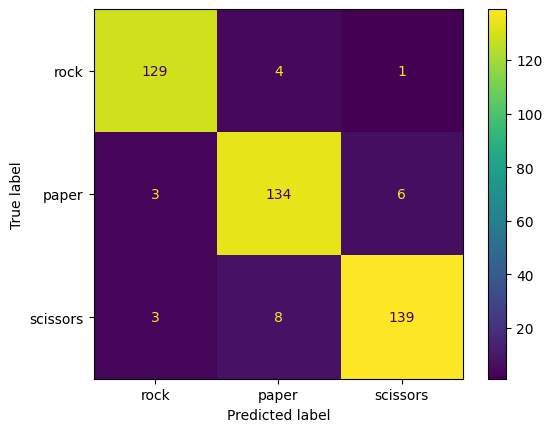

In [21]:
cm = confusion_matrix(Ytest, Ypred)
ConfusionMatrixDisplay(cm, display_labels=['rock', 'paper', 'scissors']).plot()
ac = accuracy_score(Ytest, Ypred)
print(f"Tacnost je {ac * 100} %")


Biramo obelezja 2 i 3 i klase rock i scissors

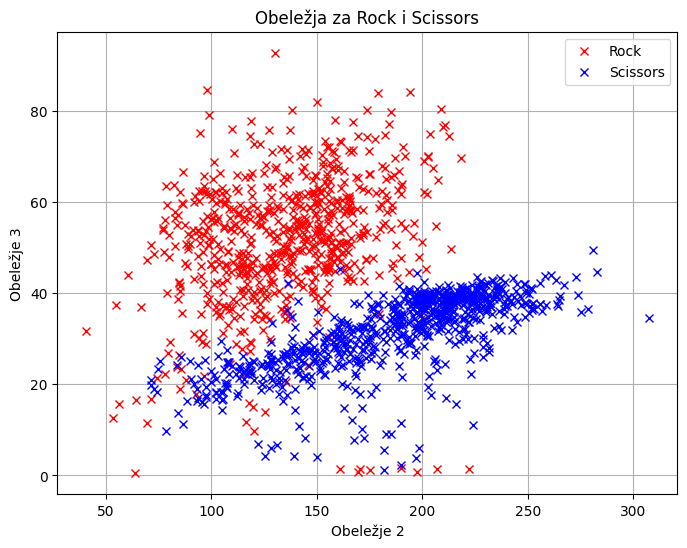

In [22]:
plt.figure(figsize=(8, 6))
plt.plot(rock_array[:, 1], rock_array[:, 2], 'rx', label='Rock')  
plt.plot(scissors_array[:, 1], scissors_array[:, 2], 'bx', label='Scissors') 

plt.xlabel('Obeležje 2')
plt.ylabel('Obeležje 3')
plt.title('Obeležja za Rock i Scissors')
plt.legend()
plt.grid()
plt.show()

Kao sto vidimo, linearnim klasifikatorom mozemo sasvim dobro razdvojiti ove dve klase.

Histogrami za obelezja 2 i 3

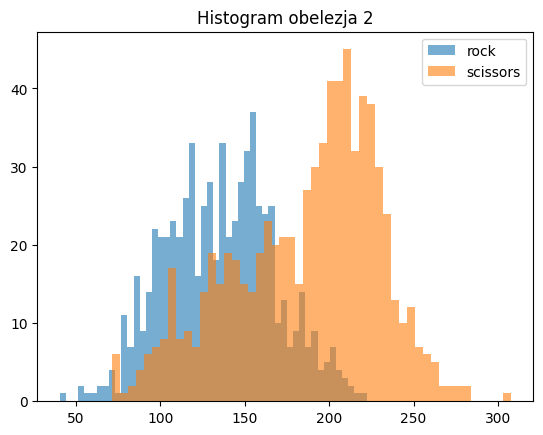

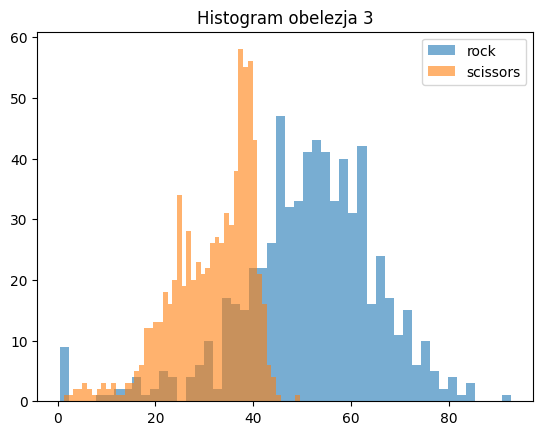

In [23]:
plt.figure()
plt.hist(rock_array[:, 1], bins=50, alpha=0.6, label='rock')
plt.hist(scissors_array[:, 1], bins=50, alpha=0.6, label='scissors')
plt.title("Histogram obelezja 2")
plt.legend(['rock', 'scissors'])
plt.show()

plt.figure()
plt.hist(rock_array[:, 2], bins=50, alpha=0.6, label='rock')
plt.hist(scissors_array[:, 2], bins=50, alpha=0.6, label='scissors')
plt.title("Histogram obelezja 3")
plt.legend(['rock', 'scissors'])
plt.show()

Iz histograma zakljucujemo da je obelezje 3 znacajnije za separabilnost, kao i to da je pretpostavka normalne raspodele bila uglavnom opravdana. Osvrnimo se na to koja obelezja su u pitanju i da li dobijeni histogrami imaju smisla:
1) obeležje 2 -> odnos sirine i visine slike u procentima - kamen ocekivano ima manji odnos
2) obeležje 3 -> procenat belih piksela na cetvrtini slike sleva - makaze ocekivano zauzimaju manju povrsinu leve strane slike

Prvo moramo ponovo da procenimo srednje vrednosti i kovarijacione matrice za izdvojene klase i obelezja. Zatim cemo parametre linearnog klasifikatora traziti iterativno, primenom metode resupstitucije, odnosno koristeci ceo skup podataka:

In [24]:
rock23 = rock_array[:, 1:]
scissors23 = scissors_array[:, 1:]

M0 = np.mean(rock23, axis = 0)
M2 = np.mean(scissors23, axis = 0)

S0 = np.cov(rock23, rowvar = False) # izmedju kolona, ne redova
S2 = np.cov(scissors23, rowvar = False)

In [25]:
s_vals = np.arange(0, 1, 0.001)
v0allbest = []
Eallbest = []
for s in s_vals:
    V = np.linalg.inv(s*S0 + (1-s) * S2) @ (M2-M0)
    sigma0 = V.T @ S0 @ V
    sigma2 = V.T @ S2 @ V
    Y0 = V.T @ rock23.T
    Y2 = V.T @ scissors23.T
    Y = np.sort(np.concatenate((Y0, Y2), axis = 0))
    N = len(Y)
    Y = Y.reshape((N, 1))
    
    V0 = []
    E = []
    for i in range(N-1):
        v0 = -(Y[i] + Y[i+1])/2
        e = np.sum(Y2 + v0 < 0) + np.sum(Y0 + v0 > 0)
        V0.append(v0)
        E.append(e)
    bestindex = np.argmin(E)
    v0allbest.append(V0[bestindex])
    Eallbest.append(E[bestindex])

bestindex2 = np.argmin(Eallbest)
sbest = s_vals[bestindex2]
Ebest = Eallbest[bestindex2]
v0best = v0allbest[bestindex2]

Odredjivanje najboljeg V i iscrtavanje klasifikacione krive ax1+bx2+v0 = 0

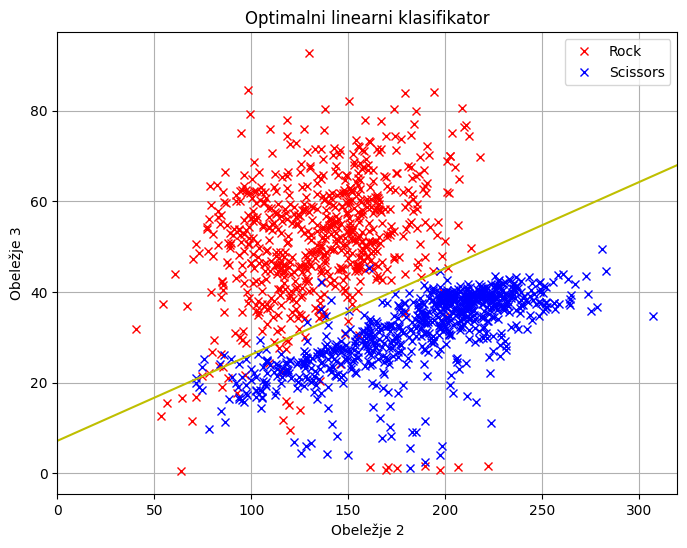

In [26]:
Vbest = np.linalg.inv(sbest*S0 + (1-sbest) * S2) @ (M2-M0)
a = Vbest[0]
b = Vbest[1]

x2 = np.linspace(0,90, 100) 
x1 = (-b * x2 - v0best)/a

plt.figure(figsize=(8, 6))
plt.plot(rock_array[:, 1], rock_array[:, 2], 'rx', label='Rock')  
plt.plot(scissors_array[:, 1], scissors_array[:, 2], 'bx', label='Scissors')
plt.plot(x1, x2, 'y-')

plt.xlabel('Obeležje 2')
plt.ylabel('Obeležje 3')
plt.xlim([0, 320])
plt.title('Optimalni linearni klasifikator')
plt.legend()
plt.grid()
plt.show()